### reading dataset

In [23]:
import pandas as pd
df=pd.read_csv('train.csv')
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
1          2  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
2          3  CA-2017-138688  12-06-2017  16-06-2017    Second Class   
3          4  US-2016-108966  11-10-2016  18-10-2016  Standard Class   
4          5  US-2016-108966  11-10-2016  18-10-2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21-05-2017  28-05-2017  Standard Class   
9796    9797  CA-2016-128608  12-01-2016  17-01-2016  Standard Class   
9797    9798  CA-2016-128608  12-01-2016  17-01-2016  Standard Class   
9798    9799  CA-2016-128608  12-01-2016  17-01-2016  Standard Class   
9799    9800  CA-2016-128608  12-01-2016  17-01-2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [24]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [25]:
df.shape

(9800, 18)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [27]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [28]:
df = df.dropna(subset=['Postal Code'])

In [29]:
df.duplicated().sum()

0

### to check the data types bcoz the order dates are in str

In [30]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [31]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [32]:
df.describe()

,Row ID,Order Date,Postal Code,Sales
count,9789.000000,9789,9789.000000,9789.000000
mean,4896.705588,2017-05-01 02:51:57.866993,55273.322403,230.116193
min,1.000000,2015-01-03 00:00:00,1040.000000,0.444000
25%,2449.000000,2016-05-23 00:00:00,23223.000000,17.248000
50%,4896.000000,2017-06-26 00:00:00,58103.000000,54.384000
75%,7344.000000,2018-05-15 00:00:00,90008.000000,210.392000
max,9800.000000,2018-12-30 00:00:00,99301.000000,22638.480000
std,2827.486899,NaN,32041.223413,625.302079


In [33]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('-', '_')

In [34]:
df.columns = df.columns.str.lower()

In [35]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='str')

In [36]:
df['year'] = df['order_date'].dt.year

In [37]:
df['month'] = df['order_date'].dt.month

In [38]:
df.groupby('region')['sales'].sum()

region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: sales, dtype: float64

In [39]:
monthly_sales = df.groupby('month')['sales'].sum()

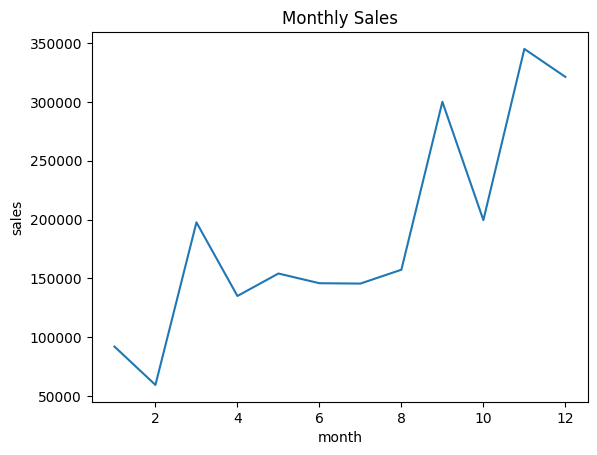

In [40]:
import matplotlib.pyplot as plt

monthly_sales.plot()
plt.xlabel('month')
plt.ylabel('sales')
plt.title('Monthly Sales')
plt.show()

In [41]:
df.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,year,month
0,1,CA-2017-152156,2017-11-08,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11
1,2,CA-2017-152156,2017-11-08,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11


In [42]:
#step 1:connect to postgreSQL database
# replace placeholders with your actual details
from sqlalchemy import create_engine


username='postgres'
password='postgres'
host='localhost'
port='5432'
database='orders_db'

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')
#step 2 load dataframe to postgreSQL database

table_name='orders' #choose any table name you want
df.to_sql(table_name,engine,if_exists='replace',index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'orders' in database 'orders_db'.


[322755.42059394 343530.51847121 364305.61634848]


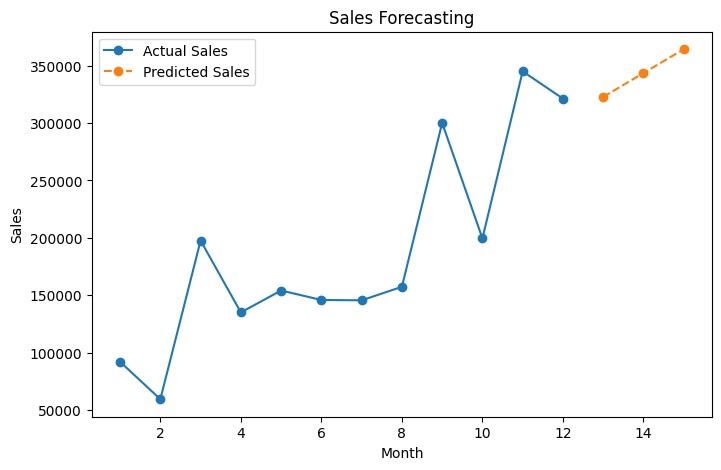

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Group sales by month
monthly_sales = df.groupby('month')['sales'].sum().reset_index()


# X and y
X = monthly_sales[['month']]
y = monthly_sales['sales']

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

# Predict future month sales
future_months = pd.DataFrame({'month': [13,14,15]})

predictions = model.predict(future_months)

# Print predictions
print(predictions)

# Plot
plt.figure(figsize=(8,5))

plt.plot(monthly_sales['month'], y, marker='o', label='Actual Sales')

plt.plot(future_months['month'],
         predictions,
         marker='o',
         linestyle='--',
         label='Predicted Sales')

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales Forecasting')
plt.legend()

plt.show()